# NODE / UDE - Remaining Useful Life (NASA C-MAPSS)

Este notebook implementa:

- Preprocesamiento de datos
- Construcción de RUL y probabilidad de falla
- NODE (Neural ODE)
- UDE (Universal Differential Equation)

In [1]:
using Pkg
Pkg.activate(".")

#solo la primera vez:
#Pkg.instantiate()

  Activating project at `c:\Users\Sebastian\Desktop\TP-DegradacionDeMotores\mi_entorno`


## Todas los paquetes que utilizaremos.

In [3]:
ENV["GKSwstype"] = "100"

using CSV
using DataFrames
using Statistics
using Plots

using Lux
using ComponentArrays
using Random
Random.seed!(42)

using OrdinaryDiffEq
using SciMLSensitivity

using Optimization
using OptimizationOptimisers
using Zygote

## Carga de datos

In [4]:
dataset_path = joinpath(pwd(), "..", "CMaps", "train_FD001.txt")

train_df = CSV.read(
    dataset_path,
    DataFrame;
    delim=' ',
    ignorerepeated=true,
    header=false
)


#agregamos los nombres de la columnas ya que el dataset original venian sin ellos
rename!(
    train_df,
    vcat(
        ["unit", "cycle", "setting1", "setting2", "setting3"],
        ["s$i" for i in 1:21]
    )
)

first(train_df, 5)

Row,unit,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Float64,Float64,Float64
1,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.7,1400.6,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.419
2,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.0,23.4236
3,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.2,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
4,1,4,0.0007,0.0,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
5,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.0,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.8,8.4294,0.03,393,2388,100.0,38.9,23.4044


## Normalización de sensores y settings

In [5]:
#Normalizamos los datos de los sensores y settings para mejorar entrenamiento de redes neuronales.


sensor_cols = ["s$i" for i in 1:21]
setting_cols = ["setting1", "setting2", "setting3"]
    
for col in sensor_cols
    μ = mean(train_df[!, col])
    σ_col = std(train_df[!, col])
    train_df[!, col] = (train_df[!, col] .- μ) ./ σ_col
end
    
for col in setting_cols
    μ = mean(train_df[!, col])
    σ_col = std(train_df[!, col])
    train_df[!, col] = (train_df[!, col] .- μ) ./ σ_col
end

## Construcción de RUL y probabilidad de falla.

In [6]:
#Construimos el cilo de falla. En el train la falla se da en el último ciclo observado.
fail_cycles = combine(
    groupby(train_df, :unit),
    :cycle => maximum => :T_fail
)

#Obtenemos un df de la siguiente forma:
#unit    T_fail
#1       192

#Ahora mergeamos con el dataset original
train_df = leftjoin(train_df, fail_cycles, on=:unit)

#Ahora empezamos a construir la proba de falla en cada ciclo.
train_df.RUL = train_df.T_fail .- train_df.cycle

#Para construir la proba vamos a utilizar un funcion sigmoide, que sea baja           lejos de la falla y aumenta rapido cerca de la falla.
      
σ(x) = 1 / (1 + exp(-x))


#Estos hiperparametros habria que chequearlos bien...
k = 0.08
threshold = 40
    
train_df.p_fail = σ.(k .* (threshold .- train_df.RUL))

20631-element Vector{Float64}:
 5.671790689635885e-6
 6.144174602214718e-6
 6.6559014820897696e-6
 7.2102480022617275e-6
 7.810763725056275e-6
 8.461293827645233e-6
 9.16600371985333e-6
 9.929405711774312e-6
 1.0756387901826074e-5
 1.165224547006964e-5
 ⋮
 0.9282424577362486
 0.9333919644249093
 0.9381965337364114
 0.9426758241011313
 0.9468488636019362
 0.9507339939159732
 0.9543488292155562
 0.9577102281579662
 0.9608342772032357

## Ejemplo de curva de falla

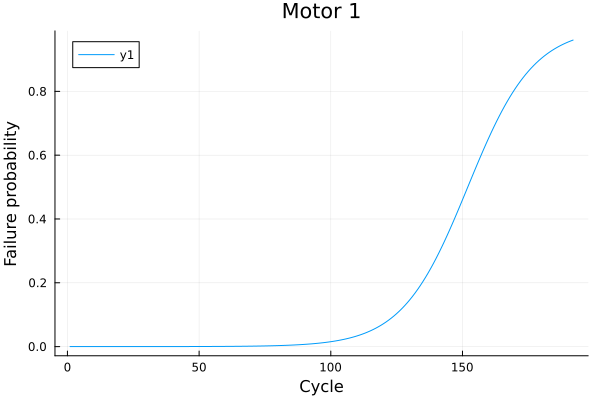

In [7]:
motor1 = filter(row -> row.unit == 1, train_df)
    
plt = plot(
    motor1.cycle,
    motor1.p_fail,
    xlabel="Cycle",
    ylabel="Failure probability",
    title="Motor 1"
)
    
plt

##  Trayectorias por motor

In [9]:
#agrupamos por unidad
grouped = groupby(train_df, :unit)
    
trajectories = []
    
for g in grouped
    X = Matrix(g[:, vcat(setting_cols, sensor_cols)])
    y = g.p_fail
    t = g.cycle
    
    push!(trajectories, (X=X, y=y, t=t))
end

##  NODE: dp/dt = NN(p, t)

NODE simple donde solo usamos los ciclos. Todavia no incorporamos sensores.

In [10]:
#elegimos una trayectoria
traj = trajectories[1]
    
t = Float64.(traj.t)
y = Float64.(traj.y)
    
u0 = [y[1]]
    
#generador de numeros aleatorios, sirve para inicializar los pesos de la red
rng = Random.default_rng()

#estructura de la red
nn = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

#p: parametros entrenables de la red, st: estados internos
p_node, st_node = Lux.setup(rng, nn)
#esto es para que funcione bien la optimizacion
p_node = ComponentArray(p_node)

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.18582273 0.073365726; -1.3326262 1.9626849; … ; -1.2206342 0.22496898; 1.2360227 0.50070494], bias = Float32[0.45274794, -0.109943174, 0.2535509, 0.33633876, -0.58940434, -0.5645052, -0.6811371, -0.25305128, 0.11489113, 0.6639945, -0.4025346, -0.6888659, -0.4826754, 0.3613354, 0.48929778, -0.21674016]), layer_2 = (weight = Float32[0.3199716 0.046035804 … 0.03958083 -0.19888853], bias = Float32[-0.0893096]))

Definimos la NODE

In [11]:
function node!(du, u, p, t)
    input = [u[1], t]

    du .= nn(input, p, st_node)[1]
end

node! (generic function with 1 method)

In [12]:
#todo el intervalo de tiempo
tspan = (t[1], t[end])
	
#definimos el problema de ode
prob_node = ODEProblem(node!, u0, tspan, p_node)
	
#resolvemos con solver numerico
sol = solve(prob_node, Tsit5(), saveat=t)

┌ Warning: Mixed-Precision `matmul_cpu_fallback!` detected and Octavian.jl cannot be used for this set of inputs (C [Matrix{Float64}]: A [Base.ReshapedArray{Float32, 2, SubArray{Float32, 1, Vector{Float32}, Tuple{UnitRange{Int64}}, true}, Tuple{}}] x B [Matrix{Float64}]). Falling back to generic implementation. This may be slow.
└ @ LuxLib.Impl C:\Users\Sebastian\.julia\packages\LuxLib\zPBrt\src\impl\matmul.jl:194


retcode: Success
Interpolation: 1st order linear
t: 192-element Vector{Float64}:
   1.0
   2.0
   3.0
   4.0
   5.0
   6.0
   7.0
   8.0
   9.0
  10.0
   ⋮
 184.0
 185.0
 186.0
 187.0
 188.0
 189.0
 190.0
 191.0
 192.0
u: 192-element Vector{Vector{Float64}}:
 [5.671790689635885e-6]
 [-0.6389859493328393]
 [-1.1971182814602073]
 [-1.690072756169595]
 [-2.1514591085398314]
 [-2.5924914293618455]
 [-3.0142288955066787]
 [-3.41512428090587]
 [-3.7941918771853764]
 [-4.152477724694881]
 ⋮
 [-73.60671244711838]
 [-74.01172685927285]
 [-74.41675030417355]
 [-74.82178185297677]
 [-75.22682058487337]
 [-75.63186558708865]
 [-76.03691595488252]
 [-76.44197079154928]
 [-76.84702920841788]

## Predicción sin entrenamiento

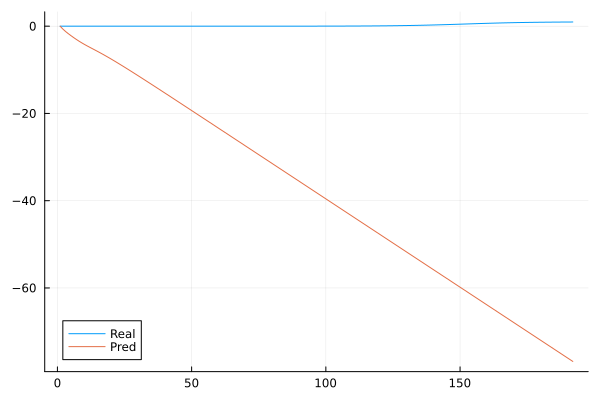

In [13]:
plt2 = plot(t, y, label="Real")
plot!(plt2, t, vec(Array(sol)), label="Pred")
	
plt2

Como se puede observar, al no haber entrenado la red no obtenemos buenos resultados.

##  Entrenamiento NODE

In [14]:
#funcion de prediccion
function predict(prob, p, t)

    _prob = remake(prob, p=p)
    
    sol = solve(
        _prob,
        Tsit5(),
        saveat=t
    )
    
    Array(sol)[1, :]
end

#funcion de perdida basica
function loss(prob, p, t, y)

    pred = predict(prob, p, t)
    
    sum(abs2, pred .- y)

end

loss (generic function with 1 method)

In [15]:
#convertimos la funcion loss en algo digerible por el optimizador. Con AutoZygote() calculamos los gradientes.
optf_node = OptimizationFunction((x, _) -> loss(prob_node,x,t,y), AutoZygote())

#Define el problema de opt. Quiero minimizar optf empezando de parametros iniciales p.
optprob_node = OptimizationProblem(optf_node, p_node)

#Resulve el problema de opt. Con Adam version de descenso por el gradiente y 0.01 el learning rate.
result_node = Optimization.solve(optprob_node, Adam(0.01), maxiters=500)
	
p_trained_node = result_node.u

#prediccion final luego de entrenar:
pred_node = predict(prob_node, p_trained_node, t)

192-element Vector{Float64}:
  5.671790689635885e-6
 -0.04486189459213208
 -0.09923701153516558
 -0.10557307590261993
 -0.08825253220874044
 -0.06583979844147159
 -0.0454655777956574
 -0.028559856620187892
 -0.01470540925328058
 -0.003102457060216534
  ⋮
  0.5138622514178848
  0.5163580730718544
  0.5190931110050987
  0.5218390301951028
  0.5244324199162117
  0.5268896469724834
  0.5294020026491865
  0.5320855595302143
  0.5347326611146708

Graficamos la sol obtenida

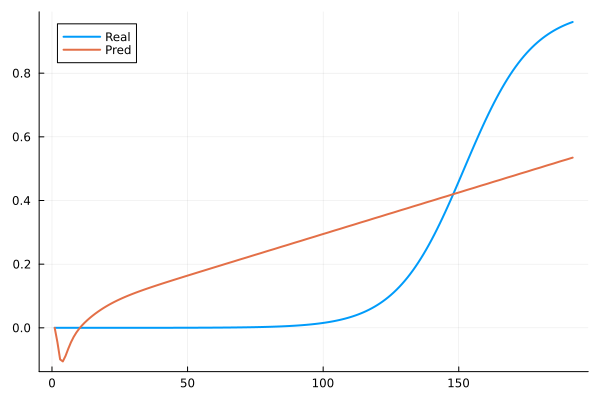

In [16]:
p1 = plot(
        t,
        y,
        label="Real",
        linewidth=2
    )
    
plot!(
    p1,
    t,
    pred_node,
    label="Pred",
    linewidth=2
)

p1

##  UDE: término físico + red neuronal

dp/dt = -αu + NN(p,t) 

In [17]:
#Definimos la red
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

#parametros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)
    
α = 0.05

#definimos ude
function ude!(du, u, p, t)

input = [u[1], t]
du .= .-α .* u .+ nn2(input, p, st_ude)[1]

end

#definimos problema ode
prob_ude = ODEProblem(ude!, u0, tspan, p_ude)

#mismo proceso de antes
optf_ude = OptimizationFunction(
(x, _) -> loss(prob_ude,x,t,y),
AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u
pred_ude = predict(prob_ude, p_trained_ude, t)

192-element Vector{Float64}:
 5.671790689635885e-6
 0.01001693725453021
 0.014888588404793629
 0.013339684623135459
 0.012646724397608477
 0.013027048314762727
 0.01347481030924492
 0.013476376014399306
 0.013004675309415023
 0.012242592109516165
 ⋮
 0.7644591908841722
 0.7722616118269156
 0.7800457338504894
 0.787811210780998
 0.7955577844637031
 0.8032852847630239
 0.8109936295625374
 0.818682824764978
 0.8263529642922387

Graficamos la sol obtenida:

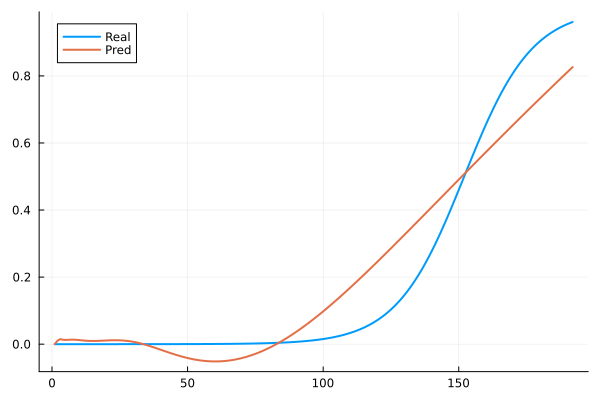

In [18]:
p2 = plot(
    t,
    y,
    label="Real",
    linewidth=2
    )
    
plot!(
    p2,
    t,
    pred_ude,
    label="Pred",
    linewidth=2
)